# 01 — MNIST Data, Shapes, Preprocessing, and Data Contracts

Before learning neural networks, learn the **data contract**. Most production model failures are not caused by calculus; they are caused by mismatched shapes, scales, labels, dtypes, preprocessing, or distribution shifts.

An MNIST sample starts as an integer matrix of shape `(28, 28)` with values in `[0, 255]`. The ANN expects a floating-point vector of length `784`, normalized to `[0, 1]`.


In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / 'mnist.npz'
MNIST_URL = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
if not MNIST_PATH.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
with np.load(MNIST_PATH) as data:
    x_train_raw, y_train_raw = data['x_train'], data['y_train']
    x_test_raw, y_test_raw = data['x_test'], data['y_test']
print('raw train:', x_train_raw.shape, y_train_raw.shape)
print('raw test :', x_test_raw.shape, y_test_raw.shape)


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    ids = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        ids.extend(rng.choice(candidates, size=per_class, replace=False))
    ids = np.array(ids)
    rng.shuffle(ids)
    return x[ids], y[ids]

x_train, y_train = balanced_subset(x_train_raw, y_train_raw, 500)
x_test, y_test = balanced_subset(x_test_raw, y_test_raw, 100)
X_train = x_train.reshape(len(x_train), -1).astype('float32') / 255.0
X_test = x_test.reshape(len(x_test), -1).astype('float32') / 255.0
print('teaching train:', X_train.shape, y_train.shape)
print('teaching test :', X_test.shape, y_test.shape)
print('pixel range   :', float(X_train.min()), 'to', float(X_train.max()))


raw train: (60000, 28, 28) (60000,)
raw test : (10000, 28, 28) (10000,)
teaching train: (5000, 784) (5000,)
teaching test : (1000, 784) (1000,)
pixel range   : 0.0 to 1.0


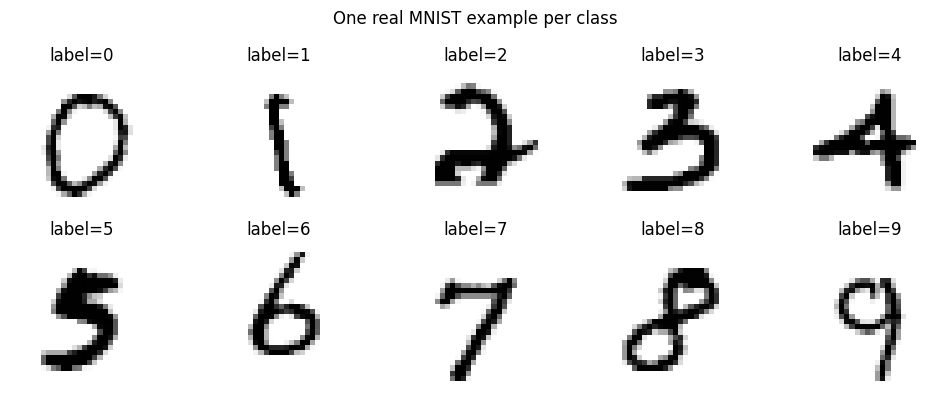

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.ravel()):
    idx = np.flatnonzero(y_train == digit)[0]
    ax.imshow(x_train[idx], cmap='gray_r')
    ax.set_title(f'label={digit}')
    ax.axis('off')
plt.suptitle('One real MNIST example per class')
plt.tight_layout()
plt.show()


## Why flattening is mathematically allowed

A dense layer consumes a vector. Flattening does **not** destroy pixel values; it changes only their indexing convention:

$$
\mathbf{x}\in\mathbb{R}^{28\times28}\longrightarrow\mathbf{x}_{flat}\in\mathbb{R}^{784}
$$

The trade-off is that a dense network no longer gets spatial locality for free. CNNs solve that differently, but this branch intentionally uses a dense ANN so every multiplication remains easy to inspect.


In [3]:
sample = X_train[0]
print('flattened sample shape:', sample.shape)
print('first 30 normalized pixels:', np.round(sample[:30], 3))
print('non-zero pixel fraction:', np.mean(sample > 0))
print('label:', int(y_train[0]))


flattened sample shape: (784,)
first 30 normalized pixels: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
non-zero pixel fraction: 0.16326530612244897
label: 9


## Production inference contract

The exact same preprocessing used during training must be reproduced at inference time. If production sends `[0,255]` values while training used `[0,1]`, the model sees a radically different input distribution. Treat preprocessing as part of the model interface, not as disposable notebook code.
